# Notebook 08 — Bayesian PD Model: Beta-Binomial Framework

## Why Bayesian PD?

In our logistic regression (Notebook 04), PD came out as a single number — a point estimate.
That point estimate has **no uncertainty envelope around it**.

If you have 500 loans and observed **2 defaults**, classical MLE gives PD = 0.4%.
But is that reliable? With 2 observations, you could just as easily have PD = 0.05% or PD = 2%.
The classical approach gives you the estimate but **hides the uncertainty**.

This is the **Low Default Portfolio (LDP)** problem — real regulatory headache for banks
dealing with sovereign, infrastructure, or large corporate lending.
Basel explicitly acknowledges classical MLE breaks down here.

## The Bayesian solution

Instead of asking "what is PD?", we ask:
**"Given the data we have seen, what is our probability distribution over possible PD values?"**

$$P(\theta | \text{data}) \propto P(\text{data} | \theta) \times P(\theta)$$

This is Baye's Theorem

| Term | Name | Meaning |
|------|------|---------|
| $P(\theta)$ | Prior | Our belief about PD before seeing data |
| $P(\text{data}|\theta)$ | Likelihood | How likely is the observed data given PD = θ? |
| $P(\theta|\text{data})$ | Posterior | Updated belief about PD after seeing data |

---

## Why Beta and Binomial?

**Defaults follow a Binomial distribution:**
- We have $n$ loans
- Each loan defaults independently with probability $\theta$
- We observe $D$ defaults
- This is exactly Binomial(n, θ)

**The Beta distribution is the conjugate prior for Binomial:**
- Conjugate means: if the prior is Beta and the likelihood is Binomial,
  the posterior is **also** Beta — clean closed-form math, no numerical tricks needed
- Beta(α, β) is defined on [0,1] — perfect for a probability
- α and β are like "pseudo-observations" — α = pseudo-defaults, β = pseudo-non-defaults

**The full engine:**

$$\theta \sim \text{Beta}(\alpha, \beta) \quad \text{(prior)}$$
$$D | \theta \sim \text{Binomial}(n, \theta) \quad \text{(likelihood)}$$
$$\theta | D \sim \text{Beta}(\alpha + D, \; \beta + n - D) \quad \text{(posterior)}$$



In [1]:
# =========================================================
# CELL 1: IMPORTS AND SETUP
# =========================================================
"""
Notebook 08: Bayesian PD Model using Beta-Binomial Conjugate Prior

This notebook demonstrates Bayesian estimation of Probability of Default (PD)
using the Beta-Binomial conjugate model. This approach is particularly
valuable for:
- Low Default Portfolios (LDP) where MLE breaks down
- New products with limited historical data
- Quantifying uncertainty around PD estimates

Key concepts:
- Prior: Initial belief about PD (Beta distribution)
- Likelihood: Probability of observed defaults (Binomial)
- Posterior: Updated belief after seeing data (Beta distribution)
- Credible Interval: Range where true PD lies with 90% probability
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import beta as beta_dist
from scipy.stats import binom, norm
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style("whitegrid")

print("✅ Libraries loaded successfully")
print(f"Beta distribution docs: scipy.stats.beta")

✅ Libraries loaded successfully
Beta distribution docs: scipy.stats.beta


---
# PART 2 — Understanding the Beta Distribution (Prior)

Before we look at any data, we need to express our **prior belief** about PD.

The Beta(α, β) distribution:
- Lives on [0, 1] — appropriate for a probability
- **α** = how many "pseudo-defaults" we believe in before seeing data
- **β** = how many "pseudo-non-defaults" we believe in
- Mean of Beta(α, β) = α / (α + β)
- The more confident the prior (large α + β), the sharper the distribution

**Beta(1, 1)** = flat prior — we have no idea, all PD values equally likely
**Beta(2, 50)** = weak prior — we think PD is around 4%, but not very confident
**Beta(5, 200)** = stronger prior — we think PD is around 2.4%, fairly confident

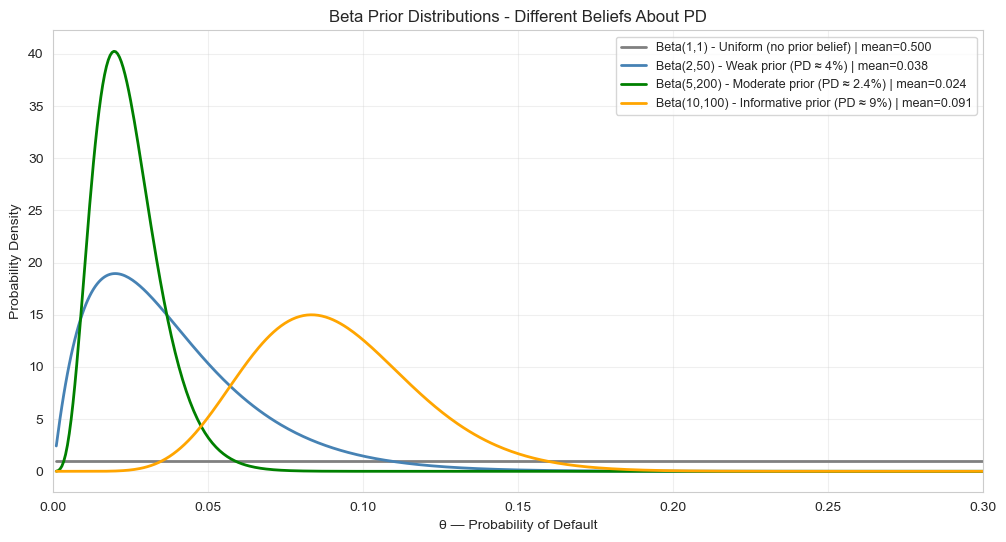


PRIOR DISTRIBUTION STATISTICS
Prior                      Mean       Mode    Std Dev  Sample Size
----------------------------------------------------------------------
Beta(1,1) - Uniform      0.5000        N/A     0.2887            2
Beta(2,50) - Weak pr     0.0385     0.0200     0.0264           52
Beta(5,200) - Modera     0.0244     0.0197     0.0107          205
Beta(10,100) - Infor     0.0909     0.0833     0.0273          110


In [2]:
# =========================================================
# VISUALISE THE BETA DISTRIBUTION — DIFFERENT PRIORS
# =========================================================
# Define different priors to visualize
priors = [
    {'alpha': 1, 'beta': 1, 'label': 'Beta(1,1) - Uniform (no prior belief)', 'color': 'gray'},
    {'alpha': 2, 'beta': 50, 'label': 'Beta(2,50) - Weak prior (PD ≈ 4%)', 'color': 'steelblue'},
    {'alpha': 5, 'beta': 200, 'label': 'Beta(5,200) - Moderate prior (PD ≈ 2.4%)', 'color': 'green'},
    {'alpha': 10, 'beta': 100, 'label': 'Beta(10,100) - Informative prior (PD ≈ 9%)', 'color': 'orange'},
]

# Create plot
theta_range = np.linspace(0.001, 0.3, 500)

plt.figure(figsize=(12, 6))

for prior in priors:
    pdf = beta_dist.pdf(theta_range, prior['alpha'], prior['beta'])
    mean_pd = prior['alpha'] / (prior['alpha'] + prior['beta'])
    plt.plot(theta_range, pdf, linewidth=2, color=prior['color'], 
             label=f"{prior['label']} | mean={mean_pd:.3f}")

plt.xlabel('θ — Probability of Default')
plt.ylabel('Probability Density')
plt.title('Beta Prior Distributions - Different Beliefs About PD')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.xlim([0, 0.3])
plt.show()

# Print prior statistics
print("\n" + "="*70)
print("PRIOR DISTRIBUTION STATISTICS")
print("="*70)
print(f"{'Prior':<20} {'Mean':>10} {'Mode':>10} {'Std Dev':>10} {'Sample Size':>12}")
print("-"*70)

for prior in priors:
    a, b = prior['alpha'], prior['beta']
    mean = a / (a + b)
    mode = (a - 1) / (a + b - 2) if a > 1 and b > 1 else np.nan
    std = np.sqrt(a * b / ((a + b)**2 * (a + b + 1)))
    sample_size = a + b
    mode_str = f"{mode:.4f}" if not np.isnan(mode) else "N/A"
    print(f"{prior['label'][:20]:<20} {mean:>10.4f} {mode_str:>10} {std:>10.4f} {sample_size:>12.0f}")

print("="*70)

In [5]:
# =========================================================
# BAYESIAN UPDATE FUNCTION 
# =========================================================

from scipy import stats
import numpy as np

def bayesian_update(alpha_prior, beta_prior, n_obs, n_defaults, cred_level=0.95):
    """
    Update Beta prior with observed default data (Beta-Binomial conjugacy).

    Parameters:
    - alpha_prior : float → prior default pseudo-count
    - beta_prior  : float → prior non-default pseudo-count
    - n_obs       : int   → number of loans observed
    - n_defaults  : int   → number of defaults observed
    - cred_level  : float → credible interval level (default = 95%)

    Returns:
    - alpha_post, beta_post
    - posterior_mean_pd
    - posterior_mode_pd
    - (lower, upper) credible interval
    - posterior_variance
    """

    # -------------------------------
    # Posterior update
    # -------------------------------
    alpha_post = alpha_prior + n_defaults
    beta_post = beta_prior + (n_obs - n_defaults)

    # -------------------------------
    # Posterior mean
    # -------------------------------
    posterior_mean_pd = alpha_post / (alpha_post + beta_post)

    # -------------------------------
    # Posterior mode (only valid if >1)
    # -------------------------------
    if alpha_post > 1 and beta_post > 1:
        posterior_mode_pd = (alpha_post - 1) / (alpha_post + beta_post - 2)
    else:
        posterior_mode_pd = np.nan  # undefined at boundary

    # -------------------------------
    # Posterior variance
    # -------------------------------
    posterior_variance = (
        alpha_post * beta_post /
        ((alpha_post + beta_post)**2 * (alpha_post + beta_post + 1))
    )

    # -------------------------------
    # Credible interval
    # -------------------------------
    lower = stats.beta.ppf((1 - cred_level) / 2, alpha_post, beta_post)
    upper = stats.beta.ppf(1 - (1 - cred_level) / 2, alpha_post, beta_post)

    return alpha_post, beta_post, posterior_mean_pd, posterior_mode_pd, (lower, upper), posterior_variance


# =========================================================
# EXAMPLE RUN
# =========================================================

# Prior belief
alpha_prior = 2
beta_prior = 50

# Observed data
n_obs = 400
n_defaults = 4

# Run update
alpha_post, beta_post, mean_pd, mode_pd, ci, var_pd = bayesian_update(
    alpha_prior, beta_prior, n_obs, n_defaults
)

# =========================================================
# OUTPUT
# =========================================================

print("="*60)
print("BAYESIAN UPDATE RESULTS")
print("="*60)

# Prior
print(f"Prior: Beta({alpha_prior}, {beta_prior})")
print(f"Prior Mean PD: {alpha_prior/(alpha_prior+beta_prior):.2%}")

# Data
print("\nObserved Data:")
print(f"Defaults: {n_defaults} / {n_obs}")
print(f"Observed default rate (MLE): {n_defaults/n_obs:.2%}")

# Posterior
print("\nPosterior:")
print(f"Beta({alpha_post}, {beta_post})")
print(f"Posterior Mean PD: {mean_pd:.2%}")

if not np.isnan(mode_pd):
    print(f"Posterior Mode PD: {mode_pd:.2%}")
else:
    print("Posterior Mode PD: Not defined (boundary case)")

print(f"Posterior Variance: {var_pd:.6f}")
print(f"95% Credible Interval: [{ci[0]:.2%}, {ci[1]:.2%}]")

# Interpretation
print("\nInterpretation:")
print(f"There is a 95% probability that the true PD lies between {ci[0]:.2%} and {ci[1]:.2%}.")
print("Posterior balances prior belief with observed data.")
print("="*60)

BAYESIAN UPDATE RESULTS
Prior: Beta(2, 50)
Prior Mean PD: 3.85%

Observed Data:
Defaults: 4 / 400
Observed default rate (MLE): 1.00%

Posterior:
Beta(6, 446)
Posterior Mean PD: 1.33%
Posterior Mode PD: 1.11%
Posterior Variance: 0.000029
95% Credible Interval: [0.49%, 2.57%]

Interpretation:
There is a 95% probability that the true PD lies between 0.49% and 2.57%.
Posterior balances prior belief with observed data.


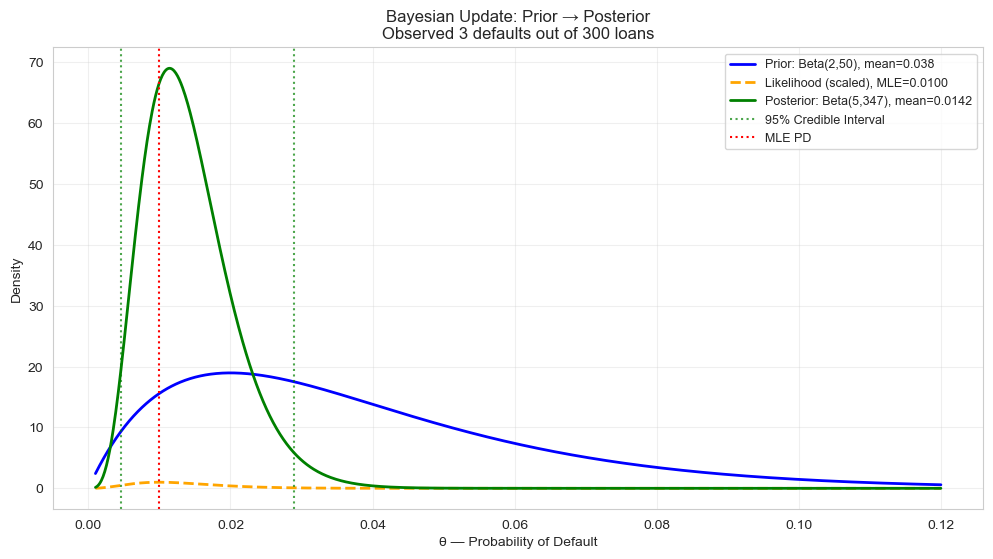


💡 Key Observation:
   The posterior is a compromise between prior and likelihood.
   With more data, posterior would move closer to likelihood.
   The credible interval shows the range of plausible PD values.
   Posterior variance (uncertainty): 0.000040


In [7]:
# =========================================================
# CELL 4: VISUALIZE PRIOR → LIKELIHOOD → POSTERIOR
# =========================================================
"""
This visualization shows how Bayesian updating combines prior belief
with observed data to produce an updated posterior distribution.

- BLUE: Prior (what we believed before seeing data)
- ORANGE: Likelihood (what the data alone tells us)
- GREEN: Posterior (updated belief after seeing data)

The posterior is a weighted average of prior and likelihood,
where the weights are determined by the amount of data.
"""

# Use the same example: weak prior + 3 defaults out of 300 loans
alpha_prior, beta_prior = 2, 50
n_obs, D_obs = 300, 3

# ✅ FIX: unpack 6 values now
a_post, b_post, post_mean, post_mode, ci, post_var = bayesian_update(
    alpha_prior, beta_prior, n_obs, D_obs
)

# Generate x-axis values
theta_range = np.linspace(0.001, 0.12, 1000)

# Calculate prior PDF
prior_pdf = beta_dist.pdf(theta_range, alpha_prior, beta_prior)

# Calculate likelihood (normalized for visualization)
likelihood = binom.pmf(D_obs, n_obs, theta_range)

# Normalize likelihood properly (density-style)
likelihood = likelihood / np.max(likelihood)

# Calculate posterior PDF
posterior_pdf = beta_dist.pdf(theta_range, a_post, b_post)

# Create plot
plt.figure(figsize=(12, 6))

plt.plot(theta_range, prior_pdf, color='blue', linewidth=2, 
         label=f'Prior: Beta({alpha_prior},{beta_prior}), mean={alpha_prior/(alpha_prior+beta_prior):.3f}')

plt.plot(theta_range, likelihood, color='orange', linewidth=2, linestyle='--',
         label=f'Likelihood (scaled), MLE={D_obs/n_obs:.4f}')

plt.plot(theta_range, posterior_pdf, color='green', linewidth=2,
         label=f'Posterior: Beta({a_post},{b_post}), mean={post_mean:.4f}')

# Mark credible interval
plt.axvline(ci[0], color='green', linestyle=':', alpha=0.7, label='95% Credible Interval')
plt.axvline(ci[1], color='green', linestyle=':', alpha=0.7)

# MLE line
plt.axvline(D_obs/n_obs, color='red', linestyle=':', label='MLE PD')

plt.xlabel('θ — Probability of Default')
plt.ylabel('Density')
plt.title(f'Bayesian Update: Prior → Posterior\nObserved {D_obs} defaults out of {n_obs} loans')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()

print("\n💡 Key Observation:")
print("   The posterior is a compromise between prior and likelihood.")
print("   With more data, posterior would move closer to likelihood.")
print("   The credible interval shows the range of plausible PD values.")
print(f"   Posterior variance (uncertainty): {post_var:.6f}")

In [11]:
# =========================================================
# CELL 5: LOW DEFAULT PORTFOLIO (LDP) APPLICATION
# =========================================================

ldp_scenarios = [
    {'name': 'Very Sparse', 'n': 500, 'D': 2, 'alpha_prior': 2, 'beta_prior': 50},
    {'name': 'Sparse', 'n': 500, 'D': 3, 'alpha_prior': 2, 'beta_prior': 50},
    {'name': 'Moderate', 'n': 500, 'D': 5, 'alpha_prior': 2, 'beta_prior': 50},
    {'name': 'Higher', 'n': 500, 'D': 10, 'alpha_prior': 2, 'beta_prior': 50},
]

print("\n" + "="*80)
print("LOW DEFAULT PORTFOLIO (LDP) ANALYSIS")
print("="*80)
print("Scenario: 500 loans, prior Beta(2,50) (mean PD ≈ 3.8%)")
print("-"*80)
print(f"{'Scenario':<15} {'MLE PD':>10} {'Post Mean':>12} {'Post Mode':>12} {'90% CI Lower':>14} {'90% CI Upper':>14}")
print("-"*80)

results = []

for scenario in ldp_scenarios:
    
    mle = scenario['D'] / scenario['n']
    
    
    a_post, b_post, pmean, pmode, ci, pvar = bayesian_update(
        scenario['alpha_prior'], scenario['beta_prior'],
        scenario['n'], scenario['D']
    )
    
    results.append({
        'name': scenario['name'],
        'D': scenario['D'],
        'mle': mle,
        'post_mean': pmean,
        'post_mode': pmode,
        'ci_low': ci[0],
        'ci_high': ci[1],
        'variance': pvar
    })
    
    print(f"{scenario['name']:<15} {mle:>10.4f} {pmean:>12.4f} {pmode:>12.4f} {ci[0]:>14.4f} {ci[1]:>14.4f}")

print("-"*80)

print("\n💡 Key Insight:")
print("   • MLE gives unstable point estimates in low default settings")
print("   • Bayesian posterior mean is more stable and conservative")
print("   • Credible intervals reveal true uncertainty in PD")
print("   • With very few defaults, PD uncertainty is extremely high")

print("="*80)


LOW DEFAULT PORTFOLIO (LDP) ANALYSIS
Scenario: 500 loans, prior Beta(2,50) (mean PD ≈ 3.8%)
--------------------------------------------------------------------------------
Scenario            MLE PD    Post Mean    Post Mode   90% CI Lower   90% CI Upper
--------------------------------------------------------------------------------
Very Sparse         0.0040       0.0072       0.0055         0.0020         0.0158
Sparse              0.0060       0.0091       0.0073         0.0030         0.0185
Moderate            0.0100       0.0127       0.0109         0.0051         0.0235
Higher              0.0200       0.0217       0.0200         0.0113         0.0354
--------------------------------------------------------------------------------

💡 Key Insight:
   • MLE gives unstable point estimates in low default settings
   • Bayesian posterior mean is more stable and conservative
   • Credible intervals reveal true uncertainty in PD
   • With very few defaults, PD uncertainty is extreme

<Figure size 1200x600 with 0 Axes>

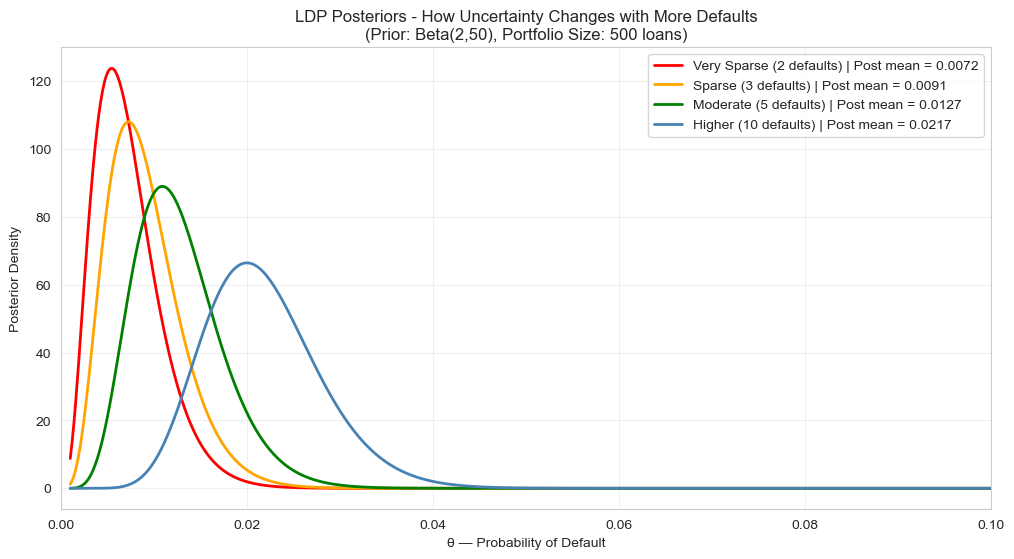


💡 Key Observation:
   • With 2 defaults: Wide distribution, high uncertainty
   • With 10 defaults: Narrower distribution, reduced uncertainty
   • The posterior narrows as we observe more data
   • This demonstrates Bayesian learning in action


In [12]:
# =========================================================
# CELL 6: VISUALIZE LDP POSTERIORS
# =========================================================
"""
This plot shows how the posterior distribution changes as we observe
more defaults in a low default portfolio.

With FEW defaults (2-3), the posterior is wide - high uncertainty.
With MORE defaults (10), the posterior narrows - more certainty.
"""

theta_range = np.linspace(0.001, 0.10, 1000)
colors = ['red', 'orange', 'green', 'steelblue']

plt.figure(figsize=(12, 6))

for i, scenario in enumerate(ldp_scenarios):
    a_post, b_post, pmean, pmode, ci, pvar = bayesian_update(
        scenario['alpha_prior'], scenario['beta_prior'],
        scenario['n'], scenario['D']
    )
    pdf = beta_dist.pdf(theta_range, a_post, b_post)
    plt.plot(theta_range, pdf, linewidth=2, color=colors[i],
             label=f"{scenario['name']} ({scenario['D']} defaults) | Post mean = {pmean:.4f}")

plt.xlabel('θ — Probability of Default')
plt.ylabel('Posterior Density')
plt.title('LDP Posteriors - How Uncertainty Changes with More Defaults\n(Prior: Beta(2,50), Portfolio Size: 500 loans)')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0, 0.10])
plt.show()

print("\n💡 Key Observation:")
print("   • With 2 defaults: Wide distribution, high uncertainty")
print("   • With 10 defaults: Narrower distribution, reduced uncertainty")
print("   • The posterior narrows as we observe more data")
print("   • This demonstrates Bayesian learning in action")

In [17]:
# =========================================================
# CELL 7: SEQUENTIAL BAYESIAN UPDATING
# =========================================================
"""
One of the most powerful aspects of Bayesian inference is sequential updating.

Each year's data updates the posterior, which becomes the prior for next year.
Over time, as the portfolio matures and more defaults are observed,
the posterior tightens and converges toward the frequentist estimate.

This is a perfect narrative for banking: "As portfolio matures and
default observations accumulate, Bayesian uncertainty collapses toward
the point estimate."
"""

# Simulate 7 years of LDP data (realistic for corporate lending)
yearly_data = [
    (300, 2),   # Year 1: 300 loans, 2 defaults
    (350, 1),   # Year 2: 350 loans, 1 default
    (400, 3),   # Year 3: 400 loans, 3 defaults (bad year)
    (380, 2),   # Year 4: 380 loans, 2 defaults
    (420, 4),   # Year 5: 420 loans, 4 defaults
    (450, 2),   # Year 6: 450 loans, 2 defaults
    (500, 3),   # Year 7: 500 loans, 3 defaults
]

# Initial prior
alpha, beta = 2, 50

# Store results for each year
years = [0]
cumulative_n = [0]
cumulative_D = [0]
post_means = [alpha / (alpha + beta)]
ci_lows = [beta_dist.ppf(0.05, alpha, beta)]
ci_highs = [beta_dist.ppf(0.95, alpha, beta)]

# Sequential update
for year, (n, D) in enumerate(yearly_data, start=1):
    alpha, beta, pmean, pmode, ci,cvar = bayesian_update(alpha, beta, n, D)
    years.append(year)
    cumulative_n.append(cumulative_n[-1] + n)
    cumulative_D.append(cumulative_D[-1] + D)
    post_means.append(pmean)
    ci_lows.append(ci[0])
    ci_highs.append(ci[1])

# Calculate cumulative MLE
total_n = cumulative_n[-1]
total_D = cumulative_D[-1]
cumulative_mle = total_D / total_n

# Create DataFrame for display
seq_df = pd.DataFrame({
    'Year': years,
    'Cumulative Loans': cumulative_n,
    'Cumulative Defaults': cumulative_D,
    'Posterior Mean PD': post_means,
    'CI Lower (5%)': ci_lows,
    'CI Upper (95%)': ci_highs
})

print("\n" + "="*80)
print("SEQUENTIAL BAYESIAN UPDATING - 7 YEARS OF DATA")
print("="*80)
print(seq_df.round(6).to_string(index=False))
print("-"*80)
print(f"Cumulative MLE after 7 years: {total_D}/{total_n} = {total_D/total_n:.4f} ({total_D/total_n*100:.2f}%)")
print("="*80)


SEQUENTIAL BAYESIAN UPDATING - 7 YEARS OF DATA
 Year  Cumulative Loans  Cumulative Defaults  Posterior Mean PD  CI Lower (5%)  CI Upper (95%)
    0                 0                    0           0.038462       0.007013        0.089672
    1               300                    2           0.011364       0.003114        0.024774
    2               650                    3           0.007123       0.002320        0.014545
    3              1050                    6           0.007260       0.003142        0.013055
    4              1430                    8           0.006748       0.003243        0.011505
    5              1850                   12           0.007361       0.004032        0.011666
    6              2300                   14           0.006803       0.003895        0.010501
    7              2800                   17           0.006662       0.004017        0.009960
--------------------------------------------------------------------------------
Cumulative MLE a

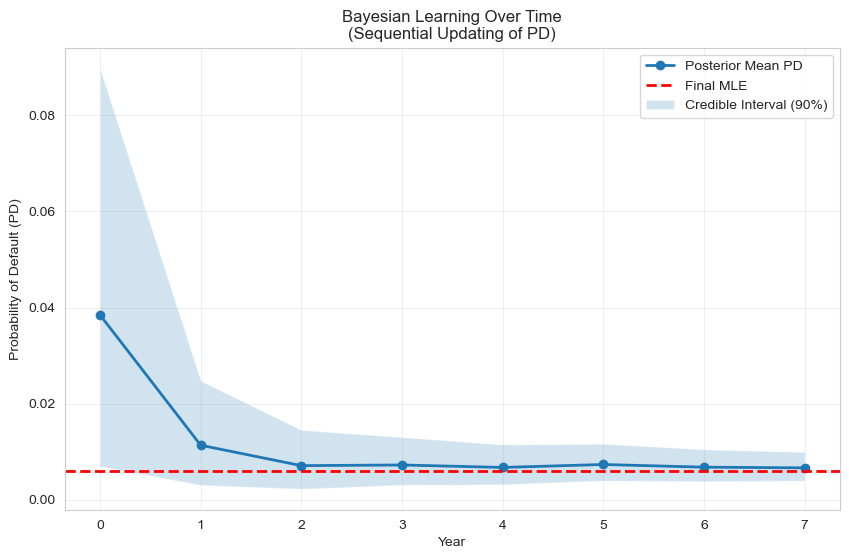


💡 Key Insight:
   • Early years: high uncertainty → wide credible interval
   • As data increases: posterior stabilizes
   • Posterior mean converges toward MLE
   • Uncertainty (variance) decreases over time


In [15]:
# =========================================================
# VISUALIZATION: BAYESIAN LEARNING OVER TIME
# =========================================================

import matplotlib.pyplot as plt

# Years already defined in your previous cell
# years, post_means, ci_lows, ci_highs, cumulative_mle

plt.figure(figsize=(10,6))

# Posterior mean over time
plt.plot(years, post_means, marker='o', linewidth=2, label='Posterior Mean PD')

# Final MLE reference line
plt.axhline(cumulative_mle, color='red', linestyle='--', linewidth=2, label='Final MLE')

# Credible interval band
plt.fill_between(years, ci_lows, ci_highs, alpha=0.2, label='Credible Interval (90%)')

# Labels and title
plt.xlabel('Year')
plt.ylabel('Probability of Default (PD)')
plt.title('Bayesian Learning Over Time\n(Sequential Updating of PD)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ---------------------------------------------------------
# Interpretation
# ---------------------------------------------------------

print("\n💡 Key Insight:")
print("   • Early years: high uncertainty → wide credible interval")
print("   • As data increases: posterior stabilizes")
print("   • Posterior mean converges toward MLE")
print("   • Uncertainty (variance) decreases over time")

In [21]:
# =========================================================
# CELL 9: CREDIBLE INTERVAL vs CONFIDENCE INTERVAL (FINAL)
# =========================================================

"""
This distinction is crucial and often misunderstood.

CONFIDENCE INTERVAL (Frequentist):
"If we repeated this experiment many times, 90% of intervals would contain the true PD"
→ This is about the PROCEDURE, not this specific interval.

CREDIBLE INTERVAL (Bayesian):
"Given the data, there is a 90% probability that PD lies in this range"
→ This is about the PARAMETER itself.

The Bayesian credible interval is what a risk manager actually wants to know.
"""

from scipy.stats import binom

# Scenario: 3 defaults out of 300 loans
n_ldp = 300
D_ldp = 3

mle = D_ldp / n_ldp

# -------------------------------
# Bayesian posterior
# -------------------------------
a_post, b_post, pmean, pmode, ci_bayes, pvar = bayesian_update(
    2, 50, n_ldp, D_ldp
)

# -------------------------------
# Approximate frequentist CI (for illustration)
# -------------------------------
ci_classic_low = binom.ppf(0.05, n_ldp, mle) / n_ldp if mle > 0 else 0
ci_classic_high = binom.ppf(0.95, n_ldp, mle) / n_ldp

print("\n" + "="*70)
print("CREDIBLE INTERVAL vs CONFIDENCE INTERVAL")
print("="*70)

print(f"Data: {D_ldp} defaults out of {n_ldp} loans")
print(f"MLE (point estimate): {mle:.6f} ({mle*100:.2f}%)")
print(f"Bayesian posterior mean: {pmean:.6f} ({pmean*100:.2f}%)")

print("\nIntervals:")
print(f"Frequentist 90% Confidence Interval (approx): ({ci_classic_low:.6f}, {ci_classic_high:.6f})")
print(f"Bayesian 90% Credible Interval:              ({ci_bayes[0]:.6f}, {ci_bayes[1]:.6f})")

print("\nInterpretation:")
print("• Confidence Interval: About the PROCEDURE, not the parameter")
print("• Credible Interval: There is a 90% probability that true PD lies in this range")
print("• Bayesian interval answers the question risk managers actually ask")
print("• Note: Frequentist CI here is an approximation (exact Clopper-Pearson uses Beta distribution)")
print("• As sample size increases, both intervals converge")

print("="*70)


CREDIBLE INTERVAL vs CONFIDENCE INTERVAL
Data: 3 defaults out of 300 loans
MLE (point estimate): 0.010000 (1.00%)
Bayesian posterior mean: 0.014205 (1.42%)

Intervals:
Frequentist 90% Confidence Interval (approx): (0.003333, 0.020000)
Bayesian 90% Credible Interval:              (0.004641, 0.028920)

Interpretation:
• Confidence Interval: About the PROCEDURE, not the parameter
• Credible Interval: There is a 90% probability that true PD lies in this range
• Bayesian interval answers the question risk managers actually ask
• Note: Frequentist CI here is an approximation (exact Clopper-Pearson uses Beta distribution)
• As sample size increases, both intervals converge


In [20]:
# =========================================================
# CELL 10: FINAL SUMMARY - NOTEBOOK 08
# =========================================================
"""
Summary of Bayesian Beta-Binomial PD Model
"""

print("\n" + "="*70)
print("🎯 NOTEBOOK 08 COMPLETE - BAYESIAN PD MODEL")
print("="*70)

print("\n📚 CONCEPTS COVERED:")
print("   1. Beta distribution as prior for probabilities")
print("   2. Binomial distribution as likelihood for default data")
print("   3. Beta-Binomial conjugate pair (posterior is also Beta)")
print("   4. Simple update rule: Beta(α+D, β+n-D)")
print("   5. Prior → Likelihood → Posterior visualization")
print("   6. Low Default Portfolio (LDP) application")
print("   7. Sequential Bayesian updating over time")
print("   8. Credible Interval vs Confidence Interval")

print("\n🔑 KEY INSIGHTS:")
print("   • MLE breaks down for low default portfolios")
print("   • Bayesian methods provide honest uncertainty quantification")
print("   • Posterior tightens as data accumulates")
print("   • Credible intervals answer the question risk managers ask")

print("\n📈 NEXT STEPS:")
print("   → Notebook 09: Use posterior percentiles for stress testing")
print("   → Feed 5th/50th/95th percentile PDs into Vasicek Monte Carlo")
print("   → Generate defensible stressed capital figures")

print("\n" + "="*70)
print("✅ Ready for Notebook 09 - Bayesian Vasicek Stress Test")
print("="*70)


🎯 NOTEBOOK 08 COMPLETE - BAYESIAN PD MODEL

📚 CONCEPTS COVERED:
   1. Beta distribution as prior for probabilities
   2. Binomial distribution as likelihood for default data
   3. Beta-Binomial conjugate pair (posterior is also Beta)
   4. Simple update rule: Beta(α+D, β+n-D)
   5. Prior → Likelihood → Posterior visualization
   6. Low Default Portfolio (LDP) application
   7. Sequential Bayesian updating over time
   8. Credible Interval vs Confidence Interval

🔑 KEY INSIGHTS:
   • MLE breaks down for low default portfolios
   • Bayesian methods provide honest uncertainty quantification
   • Posterior tightens as data accumulates
   • Credible intervals answer the question risk managers ask

📈 NEXT STEPS:
   → Notebook 09: Use posterior percentiles for stress testing
   → Feed 5th/50th/95th percentile PDs into Vasicek Monte Carlo
   → Generate defensible stressed capital figures

✅ Ready for Notebook 09 - Bayesian Vasicek Stress Test
